Importing libraries : tensorflow,keras,matplotlib etc

In [2]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML

Setting constants

In [1]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS=3
EPOCHS=50

Importing dataset 

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory( # from PlantVillage directory we are loading dataset
    r"C:\Users\DELL\OneDrive\Desktop\Tomato\Tomato_dataset",
    seed=123,
    shuffle=True, # randomly shuffle images 
    image_size=(IMAGE_SIZE,IMAGE_SIZE), # image size 
    batch_size=BATCH_SIZE
) 

Found 9835 files belonging to 4 classes.


In [ ]:
# Class names 
class_names=dataset.class_names
class_names 

['Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato_healthy']

In [5]:
# looking at the dataset 
for image_batch,labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())
# 32 images each image of 256,256 ...3:channel R,G,B

(32, 256, 256, 3)
[1 3 2 1 2 3 2 2 2 2 2 2 2 2 2 3 3 1 2 3 2 0 1 1 2 1 2 0 2 1 2 3]


In [6]:
# Print first image batch 
for image_batch,labels_batch in dataset.take(1):
    print(image_batch[0].numpy)
    

<bound method _EagerTensorBase.numpy of <tf.Tensor: shape=(256, 256, 3), dtype=float32, numpy=
array([[[146., 148., 137.],
        [146., 148., 137.],
        [147., 149., 138.],
        ...,
        [132., 130., 131.],
        [131., 129., 130.],
        [132., 130., 131.]],

       [[146., 148., 137.],
        [147., 149., 138.],
        [147., 149., 138.],
        ...,
        [133., 131., 132.],
        [132., 130., 131.],
        [132., 130., 131.]],

       [[147., 149., 138.],
        [147., 149., 138.],
        [147., 149., 138.],
        ...,
        [133., 131., 132.],
        [133., 131., 132.],
        [133., 131., 132.]],

       ...,

       [[105., 110., 103.],
        [101., 106.,  99.],
        [101., 106.,  99.],
        ...,
        [ 75.,  75.,  75.],
        [ 77.,  77.,  77.],
        [ 78.,  78.,  78.]],

       [[109., 114., 107.],
        [103., 108., 101.],
        [100., 105.,  98.],
        ...,
        [ 72.,  72.,  72.],
        [ 74.,  74.,  74.],
       

Splitting of dataset into 80/20
# splitting dataset into train test split 
# 80% data for training 
# 20 % ==> 10% for validation , 10% for test 
# test datset is used to measure accuracy of final model



In [7]:
# function for dividing dataset into train test split 
def get_dataset_partition(ds,train_split=0.8,val_split=0.1,shuffle=True, shuffle_size=10000):
    ds_size=len(ds)
    
    if shuffle:
        ds=ds.shuffle(shuffle_size,seed=12)
    
    train_size = int(ds_size*train_split)
    val_size= int(ds_size*val_split)
    
    train_ds = ds.take(train_size)
    val_ds=ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).take(val_size)
    
    return train_ds,val_ds,test_ds

In [8]:
train_ds,val_ds,test_ds=get_dataset_partition(dataset)


In [9]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
# resize the image to 256,256 then rescale b/w 0 and 1 using  tensorflow and keras 
# Do this on train ds

import tensorflow as tf
from tensorflow.keras import layers

IMAGE_SIZE = 256
BATCH_SIZE = 32

rescale_and_resize= tf.keras.Sequential(
    [
        layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),  # resize 
        layers.Rescaling(1.0/255) # normalize 
    ]
)

Data augmentation


In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [12]:

# Applying Data Augmentation to Train Dataset 
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

Making CNN Model

In [14]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 4

model = models.Sequential([
    rescale_and_resize,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape), #32 filters each of size 3*3
    layers.MaxPooling2D((2, 2)), #Max pooling 
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    
    layers.Flatten(), #Flattening such that we can enter into ANN
    
    # ANN 
    layers.Dense(64, activation='relu'), # 64 neurons 
    layers.Dense(n_classes, activation='softmax'), #last layer of 3 neurons as we have 3 classes
]) 

model.build(input_shape=input_shape)

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
# Model summary 
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 4)                │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,812 (718.02 KB)

 Trainable params: 183,812 (718.02 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Compiling the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)


In [20]:
# Training the model 
history=model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 555s 2s/step - accuracy: 0.6944 - loss: 0.8151 - val_accuracy: 0.7792 - val_loss: 0.6194
Epoch 2/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 567s 2s/step - accuracy: 0.8036 - loss: 0.5412 - val_accuracy: 0.7458 - val_loss: 0.7250
Epoch 3/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.8553 - loss: 0.3868 - val_accuracy: 0.8583 - val_loss: 0.3947
Epoch 4/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 315s 1s/step - accuracy: 0.8770 - loss: 0.3299 - val_accuracy: 0.8667 - val_loss: 0.3582
Epoch 5/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 492s 2s/step - accuracy: 0.9045 - loss: 0.2456 - val_accuracy: 0.9010 - val_loss: 0.2355
Epoch 6/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 201s 790ms/step - accuracy: 0.9021 - loss: 0.2648 - val_accuracy: 0.8823 - val_loss: 0.3005
Epoch 7/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 417s 2s/step - accuracy: 0.9235 - loss: 0.2029 - val_accuracy: 0.9260 - val_loss: 0.2066
Epoch 8/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - accuracy: 0.9320 - loss: 0.1755 - val_a

In [21]:
# Plotting accuracy and loss curve
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']


loss=history.history['loss']
val_loss=history.history['val_loss']

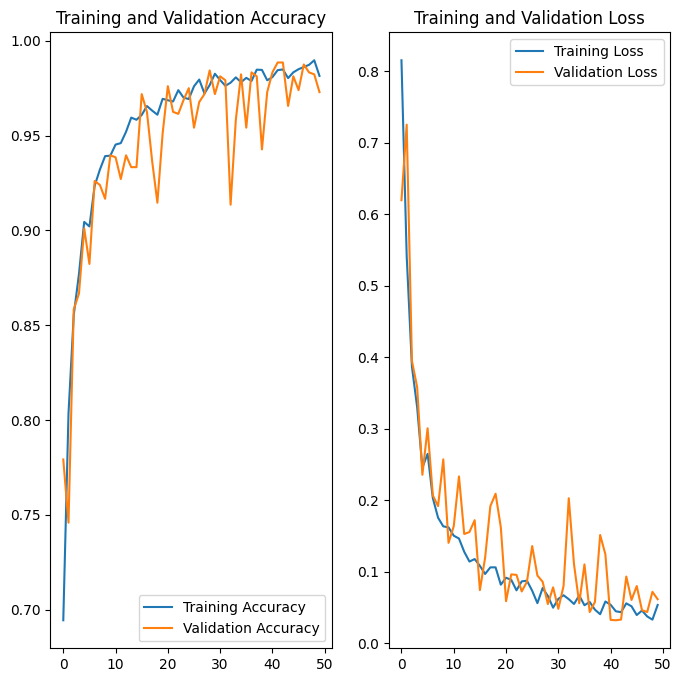

In [22]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Prediction on sample image


In [23]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


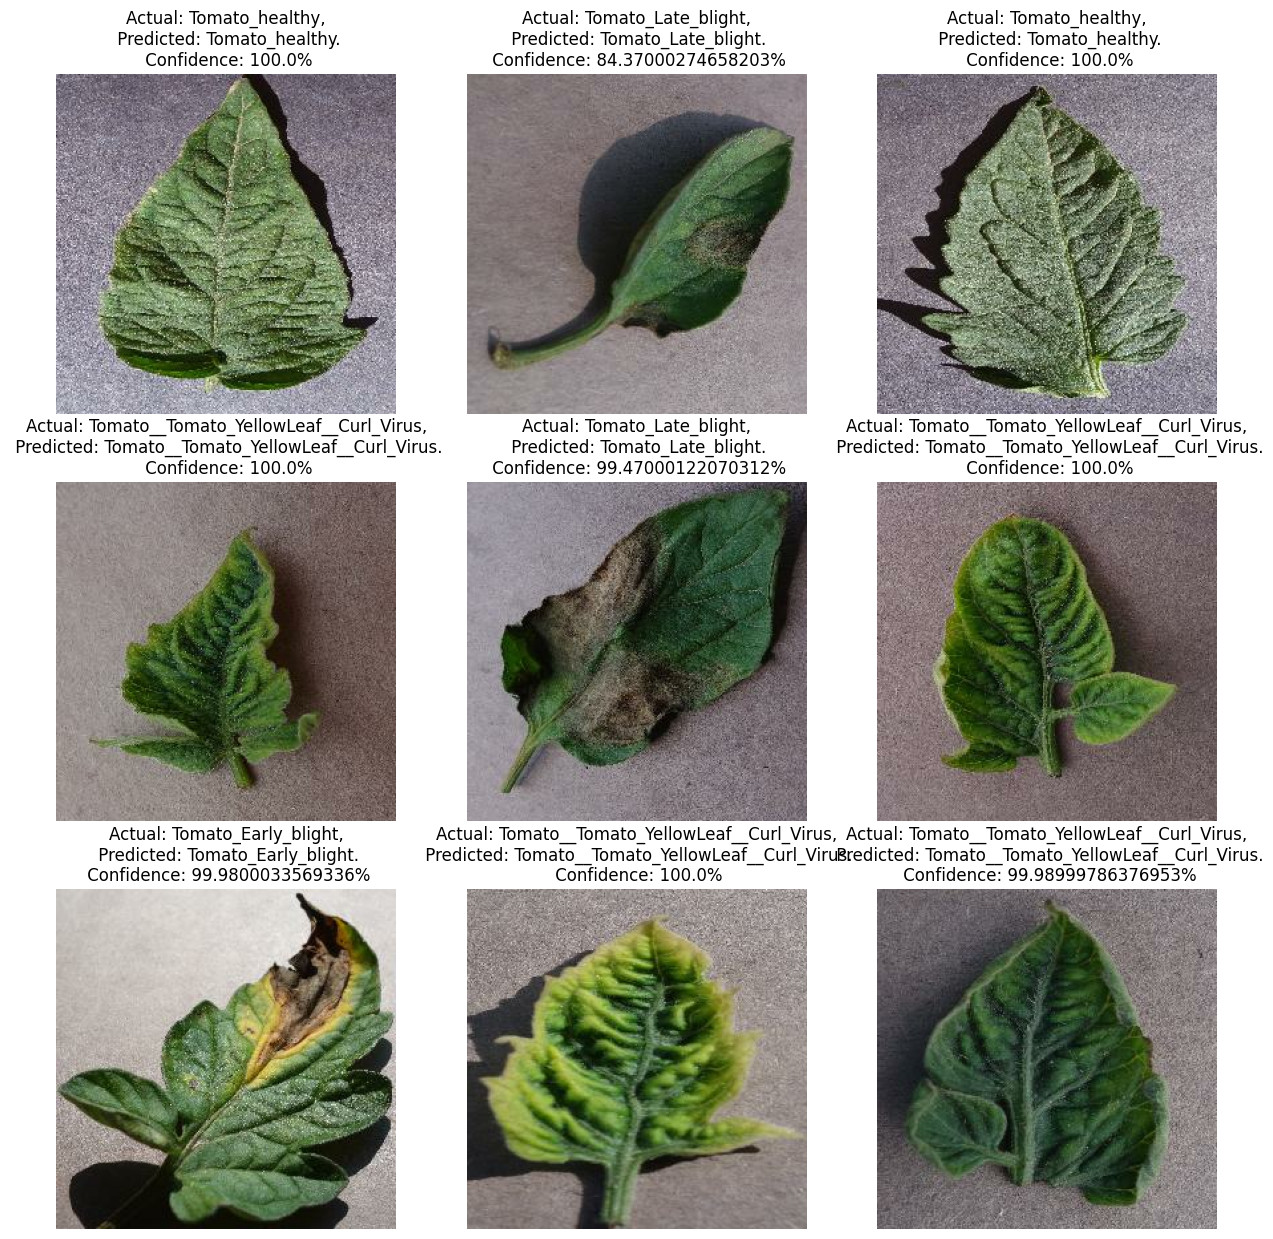

In [25]:
# inference on few sample images
import numpy as np
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

Saving the model

In [26]:
import os

model_version = 1
os.makedirs("../models", exist_ok=True)

model.save(f"../models/{model_version}.keras")
